# HW3 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [45]:
%load_ext autoreload
%autoreload 2

from hw3_loader import HW3DataLoader
from model import svm_classifier, svm_regressor
from model import evaluate_classifier, evaluate_regressor
from utils import (
    plot_classification_results,
    plot_regression_results,
    plot_residuals,
    explore_classification_data,
    apply_pca,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Loading

In [111]:
loader = HW3DataLoader()
X_clf, y_clf = loader.get_heart_disease_data('../data/heart.csv')
df_aging = loader.get_aging_data(pickle_path="../data/GSE139307.pkl")

# TODO: Inspect dataset shapes and missing values
# TODO: Print basic summary statistics for each dataset
print("shape, values counts\n", X_clf.shape, y_clf.value_counts().to_dict())
print("missing entries", X_clf.isna().sum())
print("sum missing entries", sum(X_clf.isna().sum()))
print(X_clf.describe())

# print(type(df_aging))
# print(df_aging.describe())
nas = df_aging.isna().sum()
print(nas[nas > 0])
df_aging = df_aging.dropna(axis=1, how="all")

print(df_aging.shape)

# X_aging = pd.DataFrame().from_dict(aging["methylation_data"])
# y_aging = pd.DataFrame().from_dict(aging["aging_data"])

# print("shape, values counts\n", df_aging.shape, df_aging.value_counts().to_dict())

Successfully loaded heart disease data with 1025 rows
shape, values counts
 (1025, 13) {1: 526, 0: 499}
missing entries age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64
sum missing entries 0
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

     

/Users/jahankhan/cs1851/homework-3-jahankhan/src/hw3_loader.py:84: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(f)


cg00121626       3
cg00198603       3
cg00259584       1
cg00394712       1
cg00461991       1
                ..
cg27631005       1
cg27640903       1
ch.12.643819F    2
ch.2.884792F     1
ch.4.1463482R    1
Length: 265, dtype: int64
(37, 485515)


## Classification Task (Heart Disease)

Exploring classification dataset...


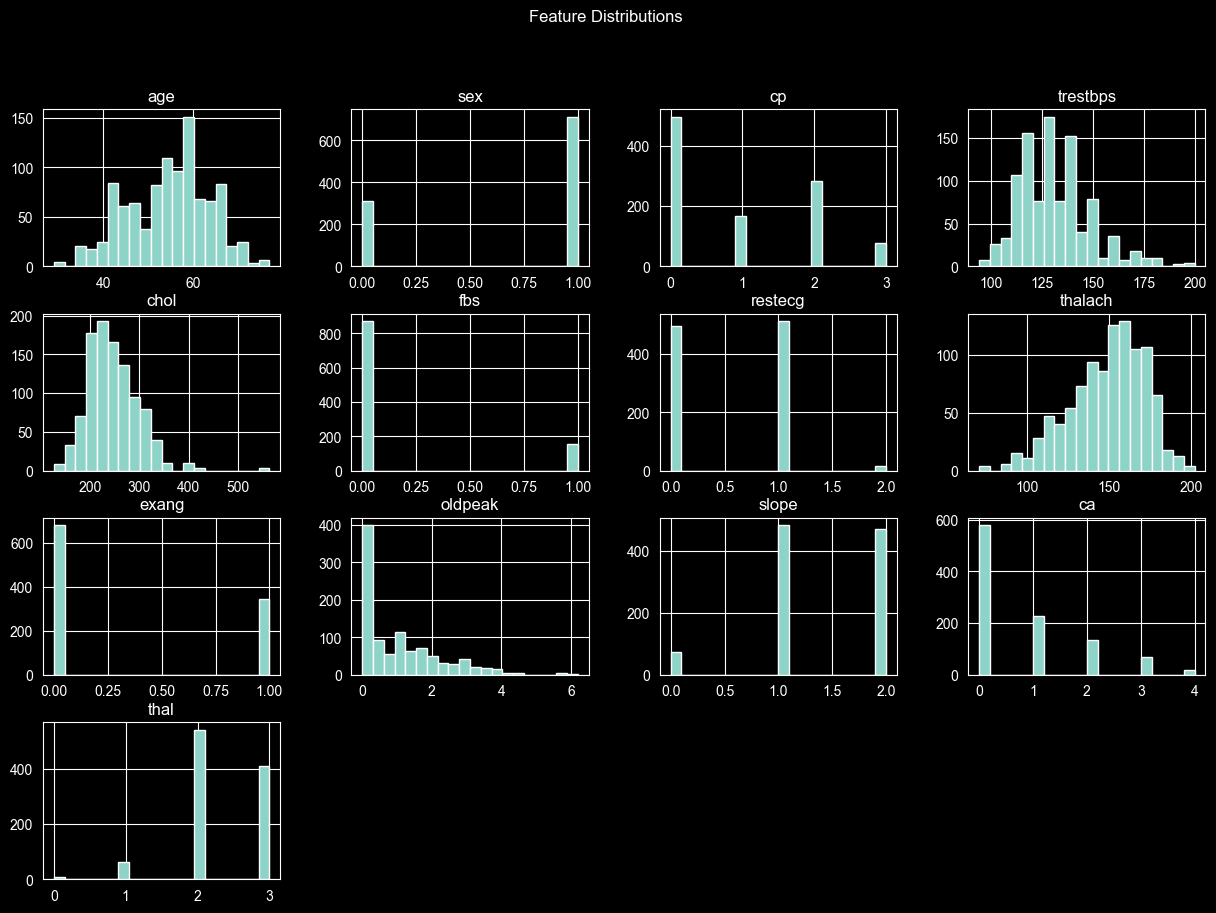

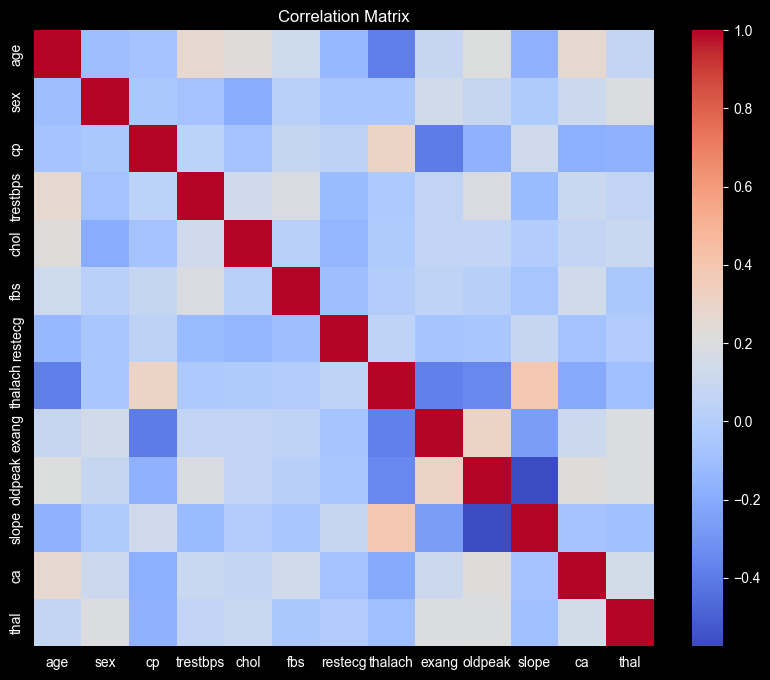

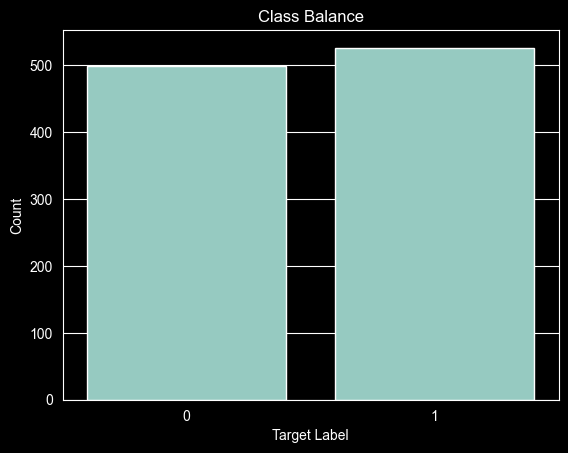

In [9]:
# TODO: Use explore_classification_data to show histograms, correlations, and class balance
# Use utils
explore_classification_data(X_clf, y_clf)

In [10]:
# TODO: Split X_clf and y_clf into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2)



### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVM)

In [103]:
# TODO: Build a leakage-free pipeline for classification
# Example skeleton:
# pipeline = Pipeline([
#     ("imputer", ...),
#     ("scaler", ...),
#     # ("pca", ...),
#     ("model", svm_classifier(kernel=..., C=..., degree=..., gamma=...)),
# ])

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=12)),
    ("model", svm_classifier()),
])


### Kernel Experiments

In [104]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model
kernels = ["linear", "poly", "rbf"]
C = [.1, 1, 10]
gamma = ["scale", "auto", .1]
degree = [2, 3, 4]

results = []

for k in kernels:
    for g in gamma:
        for c in C:
            if k == "poly":
                for d in degree:
                    pipeline.set_params(model__kernel=k, model__gamma=g, model__C=c, model__degree=d)
                    pipeline.fit(X_train, y_train)
                    metrics = evaluate_classifier(pipeline, X_test, y_test)
                    results.append({
                        "kernel": k,
                        "gamma": g,
                        "C": c,
                        "degree": d,
                        **metrics,
                    })
            else:
                pipeline.set_params(model__kernel=k, model__gamma=g, model__C=c)
                pipeline.fit(X_train, y_train)
                metrics = evaluate_classifier(pipeline, X_test, y_test)
                results.append({
                    "kernel": k,
                    "gamma": g,
                    "C": c,
                    "degree": None,
                    **metrics,
                })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by=["f1", "accuracy", "precision", "recall"], ascending=False)
print(df_results.head(20))

   kernel  gamma     C  degree  accuracy  precision    recall        f1
34   poly    0.1  10.0     3.0  0.990244   0.990414  0.990244  0.990233
44    rbf    0.1  10.0     NaN  0.990244   0.990414  0.990244  0.990233
35   poly    0.1  10.0     4.0  0.975610   0.975680  0.975610  0.975621
16   poly  scale  10.0     3.0  0.975610   0.976643  0.975610  0.975533
25   poly   auto  10.0     3.0  0.975610   0.976643  0.975610  0.975533
38    rbf  scale  10.0     NaN  0.975610   0.976643  0.975610  0.975533
41    rbf   auto  10.0     NaN  0.975610   0.976643  0.975610  0.975533
17   poly  scale  10.0     4.0  0.970732   0.970732  0.970732  0.970732
26   poly   auto  10.0     4.0  0.970732   0.970732  0.970732  0.970732
32   poly    0.1   1.0     4.0  0.960976   0.962357  0.960976  0.960823
31   poly    0.1   1.0     3.0  0.956098   0.957972  0.956098  0.955889
22   poly   auto   1.0     3.0  0.941463   0.943759  0.941463  0.941134
13   poly  scale   1.0     3.0  0.936585   0.938226  0.936585  0

### Classification Metrics and Visuals

Accuracy:  0.9902439024390244
Precision:  0.9904135737009544
ROC AUC:  0.9998076183147364


<Axes: >

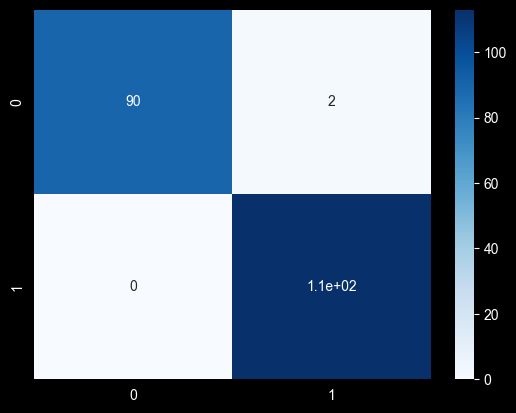

In [122]:
# TODO: Compute accuracy and F1
# TODO: Compute ROC-AUC or PR-AUC
# TODO: Plot confusion matrix and ROC/PR curve
top_model = df_results.head(1)
# print(top_model["kernel"].iloc[0])
# print(top_model["gamma"].iloc[0])
# print(top_model["C"].iloc[0])
# print(top_model["degree"].iloc[0])
if top_model["kernel"].iloc[0] == "poly":
    pipeline.set_params(model__kernel=top_model["kernel"].iloc[0], model__gamma=top_model["gamma"].iloc[0], model__C=int(top_model["C"].iloc[0]), model__degree=int(top_model["degree"].iloc[0]))
else:
    pipeline.set_params(model__kernel=top_model["kernel"].iloc[0], model__gamma=top_model["gamma"].iloc[0], model__C=int(top_model["C"].iloc[0]))

pipeline.fit(X_train, y_train)
metrics = evaluate_classifier(pipeline, X_test, y_test)

roc_auc = roc_auc_score(y_test, pipeline.decision_function(X_test))

print("Accuracy: ", metrics["accuracy"])
print("Precision: ", metrics["precision"])
print("ROC AUC: ", roc_auc)

y_pred = pipeline.predict(X_test)
classes = pipeline.classes_

cf_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)
sns.heatmap(cf_matrix, annot=True, xticklabels=classes, yticklabels=classes, cmap="Blues")


### Hyperparameter Sensitivity

<Axes: xlabel='C', ylabel='f1'>

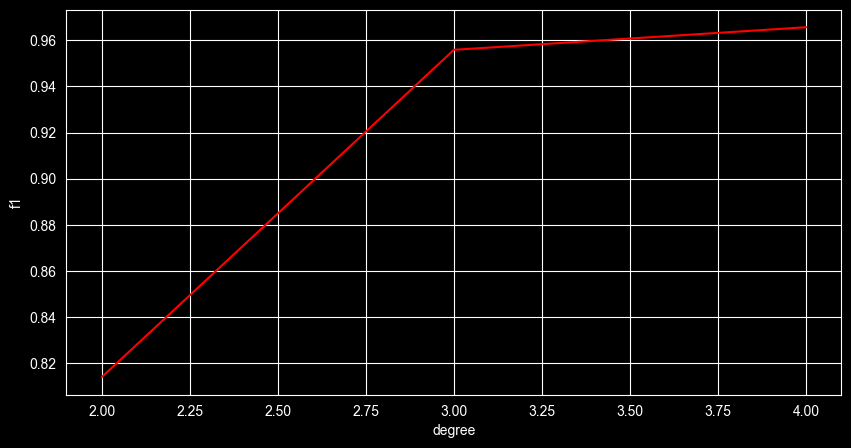

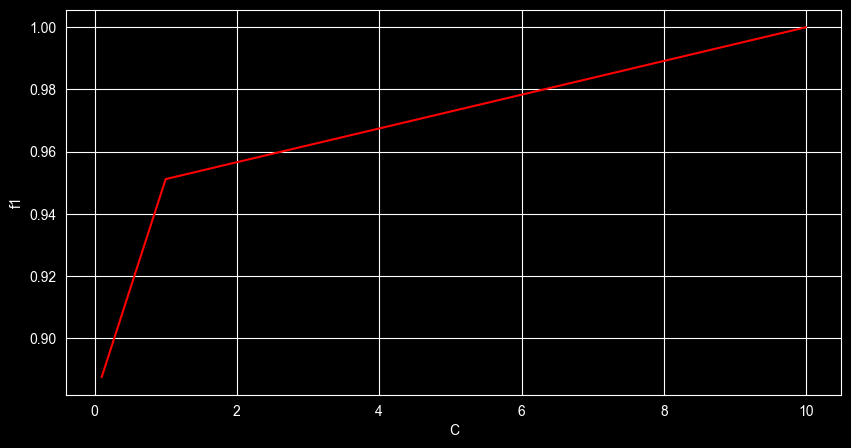

In [63]:
# TODO: Make 1-2 concise visuals of performance vs C/gamma/degree
# Example: line plot of F1 vs C for a fixed kernel
only_degrees = df_results[(df_results["kernel"] == "poly") & (df_results["C"] == 1) & (df_results["gamma"] == .1)].sort_values("degree")

plt.figure(figsize=(10, 5))
sns.lineplot(data=only_degrees, x="degree", y="f1", color="red")

only_rbf_cs = df_results[(df_results["kernel"] == "rbf") & (df_results["gamma"] == .1)].sort_values("C")

plt.figure(figsize=(10, 5))
sns.lineplot(data=only_rbf_cs, x="C", y="f1", color="red")


In [124]:
model = pipeline
plot_classification_results(X_test, y_test, model, "../classification_results.png", )


/Users/jahankhan/cs1851/homework-3-jahankhan/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


## Regression Task (Biological Aging)

In [74]:
# TODO: Separate target column "target" from features
X_reg = df_aging.drop(columns=["age", "dataset", "tissue_type", "gender"])
y_reg = df_aging["age"]

# print(X_reg.head(1))

# print(X_reg['cg01550828'].head(10))

# TODO: Handle missing values with column-wise mean imputation (do not drop rows/cols)
imputer = SimpleImputer(strategy="mean")
X_reg = pd.DataFrame(imputer.fit_transform(X_reg), columns=X_reg.columns)

# TODO: Split X_reg and y_reg into training and testing sets
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_reg, y_reg, test_size=0.2)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVR)

In [113]:
# TODO: Build a leakage-free pipeline for regression
# pipeline = Pipeline([
#     ("imputer", ...),
#     ("scaler", ...),
#     # ("pca", ...),
#     ("model", svm_regressor(kernel=..., C=..., degree=..., gamma=...)),
# ])

pipeline_a = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    # ("pca", PCA(n_components=25)),
    ("model", svm_regressor()),
])


### Kernel Experiments

In [114]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model
kernels = ["linear", "poly", "rbf"]
C = [.1, 1, 10]
gamma = ["scale", "auto", .1]
degree = [2, 3, 4]

results_a = []

for k in kernels:
    for g in gamma:
        for c in C:
            if k == "poly":
                for d in degree:
                    pipeline_a.set_params(model__kernel=k, model__gamma=g, model__C=c, model__degree=d)
                    pipeline_a.fit(X_train_a, y_train_a)
                    metrics = evaluate_regressor(pipeline_a, X_test_a, y_test_a)
                    results_a.append({
                        "kernel": k,
                        "gamma": g,
                        "C": c,
                        "degree": d,
                        **metrics,
                    })
            else:
                pipeline_a.set_params(model__kernel=k, model__gamma=g, model__C=c)
                pipeline_a.fit(X_train_a, y_train_a)
                metrics = evaluate_regressor(pipeline_a, X_test_a, y_test_a)
                results_a.append({
                    "kernel": k,
                    "gamma": g,
                    "C": c,
                    "degree": None,
                    **metrics,
                })


In [121]:
df_results_a = pd.DataFrame(results_a)
# print(df_results_a)
# print(df_result)
for col in ["r2", "mae", "rmse"]:
    df_results_a[col] = df_results_a[col].astype(float)

df_results_a = df_results_a.sort_values(by=["r2", "mae", "rmse"], ascending=[False, True, True])
print(df_results_a.head(20))


    kernel  gamma     C  degree       mae      rmse        r2
0   linear  scale   0.1     NaN  4.286433  5.244763  0.074891
1   linear  scale   1.0     NaN  4.286433  5.244763  0.074891
2   linear  scale  10.0     NaN  4.286433  5.244763  0.074891
3   linear   auto   0.1     NaN  4.286433  5.244763  0.074891
4   linear   auto   1.0     NaN  4.286433  5.244763  0.074891
5   linear   auto  10.0     NaN  4.286433  5.244763  0.074891
6   linear    0.1   0.1     NaN  4.286433  5.244763  0.074891
7   linear    0.1   1.0     NaN  4.286433  5.244763  0.074891
8   linear    0.1  10.0     NaN  4.286433  5.244763  0.074891
38     rbf  scale  10.0     NaN  4.503829  5.353782  0.036032
41     rbf   auto  10.0     NaN  4.503829  5.353782  0.036032
17    poly  scale  10.0     4.0  4.088819  5.487805 -0.012835
26    poly   auto  10.0     4.0  4.088819  5.487805 -0.012835
16    poly  scale  10.0     3.0  4.203789  5.489951 -0.013627
25    poly   auto  10.0     3.0  4.203789  5.489951 -0.013627
37     r

### Regression Metrics and Visuals

In [97]:
# TODO: Compute MAE, RMSE, and R^2
# TODO: Plot parity (predicted vs actual) and residuals
top_model_a = df_results_a.head(1)

if top_model_a["kernel"].iloc[0] == "poly":
    pipeline_a.set_params(model__kernel=top_model_a["kernel"].iloc[0], model__gamma=top_model_a["gamma"].iloc[0], model__C=top_model_a["C"].iloc[0], model__degree=int(top_model_a["degree"].iloc[0]))
else:
    pipeline_a.set_params(model__kernel=top_model_a["kernel"].iloc[0], model__gamma=top_model_a["gamma"].iloc[0], model__C=top_model_a["C"].iloc[0])

pipeline_a.fit(X_train_a, y_train_a)
metrics_a = evaluate_regressor(pipeline_a, X_test_a, y_test_a)

print(metrics_a)

y_pred_a = pipeline_a.predict(X_test_a)
# classes_a = pipeline_a.classes_

plot_regression_results(y_test_a, y_pred_a, "../regression_results.png")
plot_residuals(y_test_a, y_pred_a, "../regression_residuals.png")


{'mae': 4.286432836140548, 'rmse': np.float64(5.244763096868161), 'r2': 0.07489093205187225}


### Hyperparameter Sensitivity (Regression)

<Axes: xlabel='C', ylabel='rmse'>

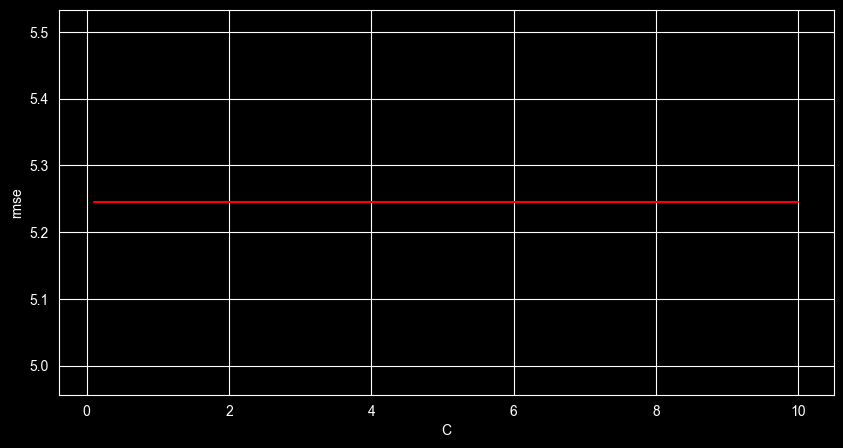

In [102]:
# TODO: Visualize performance vs C/gamma/degree
# Example: line plot of RMSE vs C for a fixed kernel
only_linear_cs = df_results_a[(df_results_a["kernel"] == "linear") & (df_results_a["gamma"] == "scale")]

plt.figure(figsize=(10, 5))
sns.lineplot(data=only_linear_cs, x="C", y="rmse", color="red")

only_linear_cs = df_results_a[(df_results_a["kernel"] == "linear") & (df_results_a["gamma"] == "scale")]

plt.figure(figsize=(10, 5))
sns.lineplot(data=only_linear_cs, x="C", y="rmse", color="red")
